Problem Statement:
Suppose you work as a Data Scientist at a bank. Every day, the bank receives numerous loan applications from customers. Reviewing each application manually is time-consuming and may lead to inconsistent decisions. Your task is to build a machine learning model that predicts whether a loan application should be Approved or Rejected based on applicant details such as income, education, CIBIL score, loan amount, loan term, and asset values. This model will help the bank make faster, more accurate, and data-driven loan approval decisions.


✔ Problem Statement
✔ Import Libraries
✔ Load Dataset
✔ Data Understanding
✔ Data Cleaning
✔ EDA
✔ Correlation Analysis
✔ Label Encoding
✔ Train-Test Split
✔ Logistic Regression
✔ Decision Tree
✔ Random Forest
✔ Model Comparison

## Step 1: Import Required Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

# Load the Dataset

The dataset contains historical loan application records along with the corresponding loan approval status. We will load the dataset into a Pandas DataFrame to begin our analysis.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-approval-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/loan-approval-prediction-dataset


In [3]:
df = pd.read_csv("/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv")

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


Check Column Names

In [5]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

## Step 3 Understanding the dataset

Before performing any data preprocessing or model building, it is important to understand the dataset. In this step, we will examine the dataset's dimensions, column names, data types, and summary statistics to gain insights into its structure and identify any potential data quality issues.

Check Dataset Shape

In [6]:
df.shape

(4269, 13)

The shape function returns the dimensions of the dataset. It tells us that our dataset contains 4,269 loan applications and 13 columns

Display Column Names

In [7]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

Remove Extra Spaces from Column Names

In [8]:
df.columns = df.columns.str.strip()

Why are we doing this?

When working with real-world datasets, column names may contain unnecessary leading or trailing spaces. Removing these spaces ensures that column names are clean and prevents errors when accessing them later in the notebook.

Verify

In [9]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

Display Random Samples

Instead of always viewing the first five rows with head(), sample() shows random records, helping us verify that values look reasonable across the dataset.

In [10]:
df.sample(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
3888,3889,1,Not Graduate,No,9100000,23300000,18,792,800000,12600000,32100000,12400000,Approved
4078,4079,3,Graduate,Yes,7800000,20000000,14,727,4600000,7200000,17300000,8600000,Approved
2064,2065,0,Graduate,No,6100000,23600000,20,856,3300000,5200000,17700000,6400000,Approved
3408,3409,0,Not Graduate,No,1900000,3800000,16,542,800000,500000,4000000,2100000,Rejected
1862,1863,2,Not Graduate,Yes,200000,600000,8,552,400000,200000,700000,200000,Approved


## Step 4: Dataset Information

In this step, we will examine the dataset in detail by checking the data types of each feature, identifying missing values, and generating summary statistics. This helps us understand the quality and characteristics of the data before performing preprocessing and model building.

Dataset Information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


The info() function provides a concise summary of the dataset. It displays the total number of rows and columns, the data type of each feature, the number of non-null values, and the memory usage. This helps us identify missing values and understand the structure of the dataset.

Interview Question

Q: Why do we use df.info()?

Answer:

To understand the structure of the dataset, check data types, and identify missing values before preprocessing.

Statistical Summary of Numerical Features

In [12]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


Summary of Categorical Features

In [13]:
df.describe(include='object')

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


This helps us understand the distribution of categorical data.

## Step 5: Data Quality Checks

Before building a machine learning model, it is important to verify the quality of the dataset. In this step, we will check for missing values, duplicate records, and unnecessary columns. Ensuring clean and reliable data improves model performance and reduces the chances of errors during training.

Check Missing Values

In [14]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


The isnull().sum() function checks each column for missing values. Missing data can negatively affect machine learning models, so it's important to identify and handle them before training."

Interview Question

Q: Why do we check for missing values?

Answer:

Missing values can lead to inaccurate predictions or errors during model training. Identifying them early allows us to decide whether to remove or impute them.

Check Duplicate Records

In [15]:
df.duplicated().sum()

np.int64(0)

Duplicate records can bias the model by giving more importance to repeated observations. Therefore, we check for duplicates and remove them if necessary.

Check Unique Values in Each Column

In [16]:
df.nunique()

,0
loan_id,4269
no_of_dependents,6
education,2
self_employed,2
income_annum,98
loan_amount,378
loan_term,10
cibil_score,601
residential_assets_value,278
commercial_assets_value,188


This gives us an idea of:

Numerical features
Categorical features
Identifier columns

It also helps us decide which columns may not be useful for prediction.

Remove the Loan ID Column

loan_id is only a unique identifier and doesn't provide any information that helps predict whether a loan should be approved.

In [17]:
df.drop("loan_id", axis=1, inplace=True)

Verify

In [18]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


The loan_id column is simply a unique identifier assigned to each loan application. Since it doesn't influence the approval decision, we remove it before training the model.

Interview Question

Q: Why shouldn't ID columns be used as input features?

Answer:

They uniquely identify records but don't contain meaningful information for prediction. Including them can introduce unnecessary noise into the model.

After checking the dataset, we can see that there are no missing values and no duplicate records. This means our dataset is already clean, and we don't need to perform any missing value imputation or duplicate removal.

Check Target Variable Distribution

In [19]:
df["loan_status"].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [20]:
df["loan_status"].value_counts(normalize=True) * 100

,proportion
loan_status,
Approved,62.215976
Rejected,37.784024


Why are we doing this?

Before training a classification model, we need to know whether the dataset is balanced or imbalanced.

If both classes have similar numbers of records → Balanced dataset ✅
If one class dominates the other → Imbalanced dataset ⚠️

This influences model selection and evaluation metrics.

## Step 6: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing the dataset to understand its underlying patterns, relationships, and distributions. It helps identify trends, detect outliers, and gain valuable insights before building a machine learning model.

Analyze the Target Variable

In [21]:
df["loan_status"].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


Let's first analyze our target variable, which is loan_status. Since this is a classification problem, it's important to understand how many applications were approved and how many were rejected. This helps us determine whether the dataset is balanced

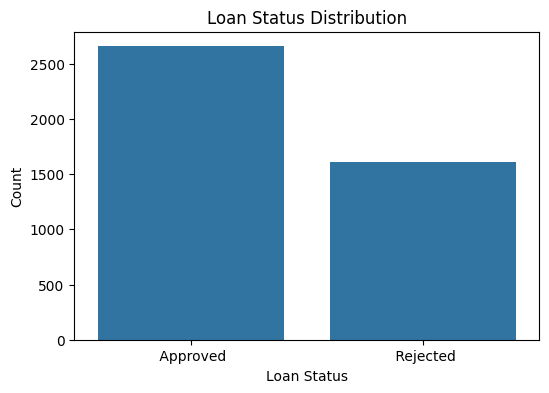

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="loan_status")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

Interview Question

Q. Why do we analyze the target variable first?

Answer:

Because it helps us understand the class distribution. If one class has significantly more samples than the other, the dataset is imbalanced, and we may need techniques like class weighting, oversampling, or undersampling.

Add Percentage Distribution

In [23]:
(df["loan_status"].value_counts(normalize=True) * 100).round(2)

,proportion
loan_status,
Approved,62.22
Rejected,37.78


loan_status
      │
      ▼
value_counts()

Approved    2656
Rejected    1613

      │
      ▼
normalize=True

Approved    0.62216
Rejected    0.37784

      │
      ▼
*100

Approved    62.216
Rejected    37.784

      │
      ▼
round(2)

Approved    62.22
Rejected    37.78

The target variable is loan_status, which contains two classes: Approved and Rejected. We observe that approximately 62% of loan applications were approved, while about 38% were rejected. The dataset is reasonably balanced, making it suitable for training classification models without requiring special techniques to handle class imbalance."

Interview Question

Q. Is this dataset balanced?

Answer:

Yes. Although the Approved class has more records than the Rejected class, the difference is not extreme. Therefore, the dataset is reasonably balanced and can be used for training classification models without immediately applying resampling techniques.

Now we'll start the actual EDA. From here onwards, we'll analyze each feature and answer two questions:

How is the feature distributed? (Univariate Analysis)
How does it affect loan approval? (Bivariate Analysis)

Analyze education

In [24]:
df["education"].value_counts()

,count
education,
Graduate,2144
Not Graduate,2125


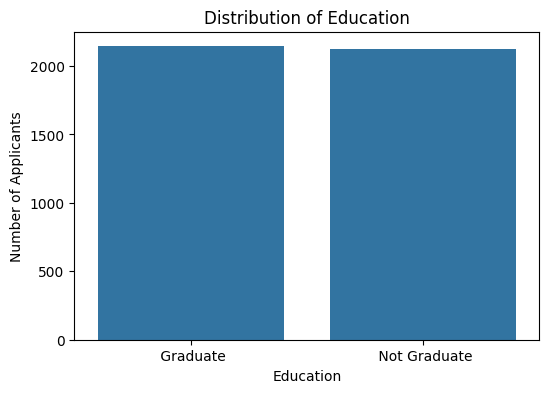

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x="education", data=df)

plt.title("Distribution of Education")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

plt.show()

sns.countplot()

This function is used to count the number of occurrences of each category and display them as bars.

sns.countplot(x="education", data=df)
x="education" → Use the education column.
data=df → The dataset from which the column is taken.

You don't need to calculate the counts yourself. countplot() internally performs a value_counts() and draws the chart.

This count plot shows the distribution of applicants based on their education level. It helps us understand whether the dataset contains more graduates or non-graduates before analyzing how education influences loan approval.

<Axes: xlabel='education', ylabel='count'>

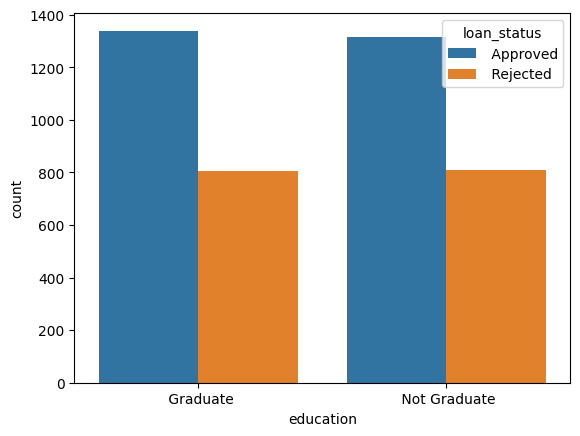

In [26]:
sns.countplot(x="education", hue="loan_status", data=df)

Based on the current visualization, both graduates and non-graduates have similar proportions of approved and rejected loans. This suggests that education alone may not be a strong predictor of loan approval. However, we cannot draw a final conclusion without further analysis and model training.

Next Feature: Self Employed

In this section, we analyze the distribution of applicants based on their employment status. This helps us understand how many applicants are self-employed versus non-self-employed before examining its relationship with loan approval.

In [27]:
df["self_employed"].value_counts()

,count
self_employed,
Yes,2150
No,2119


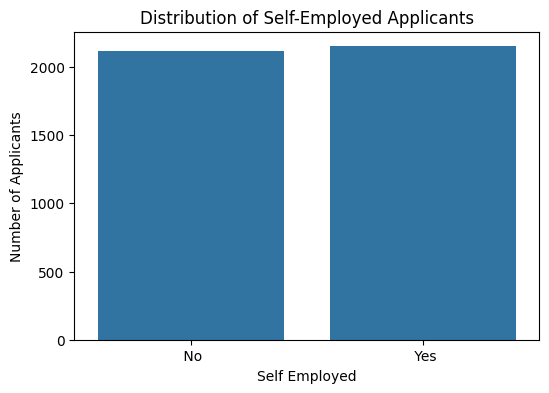

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x="self_employed", data=df)

plt.title("Distribution of Self-Employed Applicants")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")

plt.show()

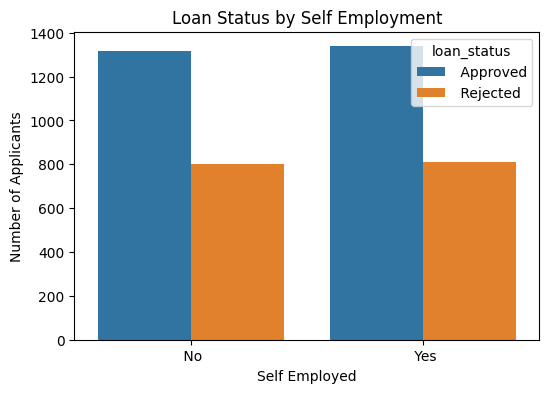

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x="self_employed", hue="loan_status", data=df)

plt.title("Loan Status by Self Employment")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")

plt.show()

This visualization helps us understand whether self-employment has any noticeable relationship with loan approval. By comparing approved and rejected applications across self-employed and non-self-employed applicants, we can observe whether employment type appears to influence the approval decision."

Income Analysis

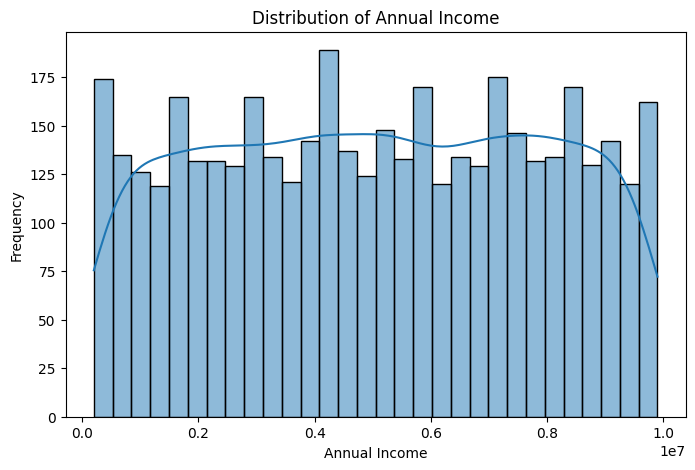

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df["income_annum"], bins=30, kde=True)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

What does bins=30 mean?

The histogram divides the income values into 30 intervals.

More bins = more detail.

Fewer bins = smoother graph.

What is kde=True?

This adds a smooth curve over the histogram.

The Kernel Density Estimation (KDE) curve helps visualize the overall shape of the data distribution without focusing on individual bars.

sns.histplot()

This is our first histogram.

Unlike countplot(), which is used for categorical data, a histogram is used for numerical data.

It groups numerical values into intervals (called bins) and shows how many observations fall into each interval.

Since annual income is a numerical feature, we use a histogram to understand its distribution. The bars show how many applicants fall within different income ranges, while the KDE curve provides a smooth representation of the overall distribution

The annual income appears to be fairly evenly distributed across different income ranges. The histogram does not exhibit the bell-shaped pattern of a normal distribution, and there are no obvious outliers visible from this plot.

Does annual income affect loan approval?

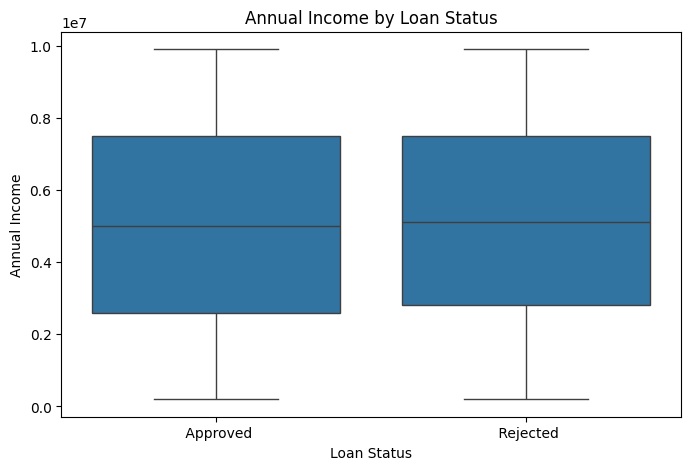

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x="loan_status", y="income_annum", data=df)

plt.title("Annual Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")

plt.show()

##Step 7: Correlation Analysis

Correlation measures the strength and direction of the relationship between numerical features. A correlation heatmap helps identify highly related variables, detect multicollinearity, and understand how different financial attributes are associated with one another.

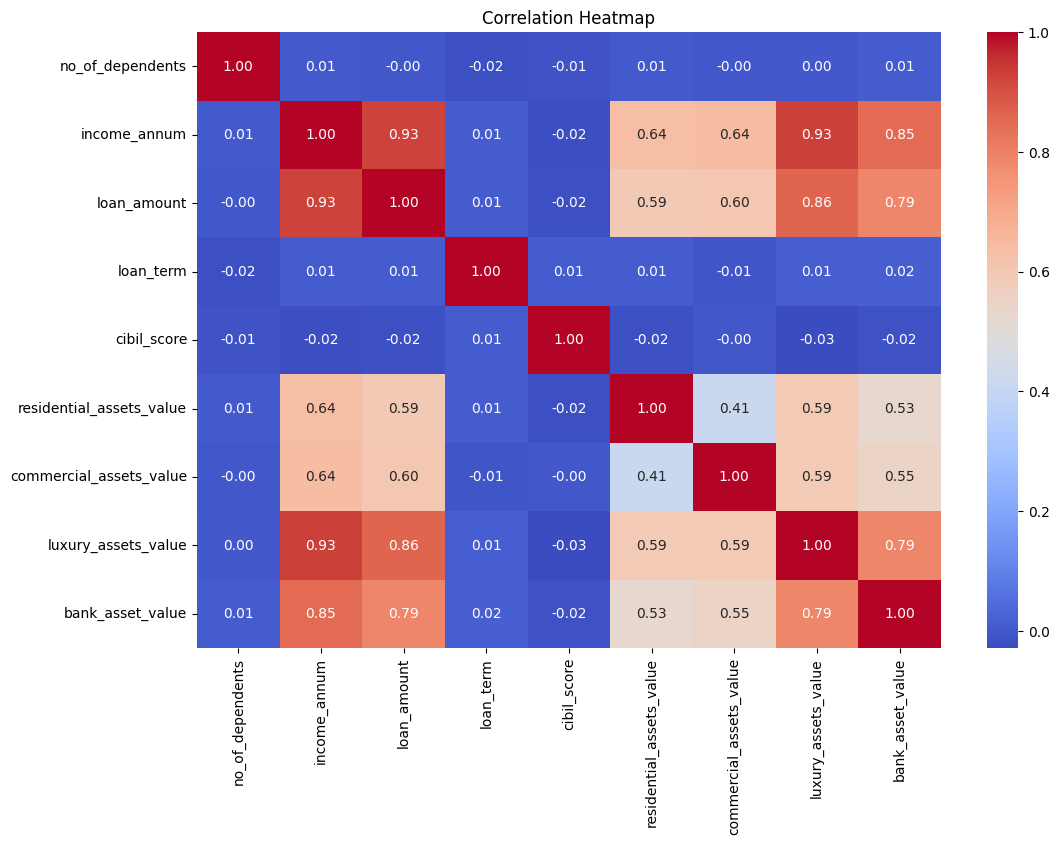

In [32]:
plt.figure(figsize=(12,8))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

A correlation heatmap helps us understand how numerical features are related to each other. Correlation values range from -1 to +1, where +1 indicates a perfect positive relationship, -1 indicates a perfect negative relationship, and 0 means there is no linear relationship. This analysis also helps identify multicollinearity before training machine learning models.

## Step 8 Data Preprocessing


Machine learning algorithms require numerical input data. In this step, we prepare the dataset by encoding categorical variables, separating the features and target variable, and making the data ready for model training.

Check Data Types

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


education         object
self_employed     object
loan_status       object

These are the columns that need to be converted into numbers.

Why do we encode?

Machine Learning algorithms work with numbers, not text.

Encoding

In [34]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder() #Create the encoder
df["education"] = label_encoder.fit_transform(df["education"]) #Encode the columns

df["self_employed"] = label_encoder.fit_transform(df["self_employed"])

df["loan_status"] = label_encoder.fit_transform(df["loan_status"])

Let's understand fit_transform()

This is one of the most common interview questions.

What does fit() do?

It learns the unique categories.
What does transform() do?

It converts them into numbers.

In [35]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


Machine learning models cannot process text directly, so we convert categorical variables into numerical values using Label Encoding. Since our categorical features have only two unique categories each, Label Encoding is a simple and appropriate choice.

Interview Question

Q. Why did you choose Label Encoding instead of One-Hot Encoding?

Answer:

We used Label Encoding because all categorical features (education, self_employed, and loan_status) are binary, meaning they each have only two unique categories. For binary features, Label Encoding is simple, efficient, and does not introduce unnecessary additional columns. One-Hot Encoding is generally preferred when a feature has more than two categories without any inherent order.

I don't want to encode all three columns using the same LabelEncoder object as many tutorials do. It works here, but it's not a good habit.

A cleaner approach is:

In [36]:
from sklearn.preprocessing import LabelEncoder

education_encoder = LabelEncoder()
self_employed_encoder = LabelEncoder()
loan_status_encoder = LabelEncoder()

df["education"] = education_encoder.fit_transform(df["education"])
df["self_employed"] = self_employed_encoder.fit_transform(df["self_employed"])
df["loan_status"] = loan_status_encoder.fit_transform(df["loan_status"])

##Step 9: Feature Selection and Train-Test Split

Before training a machine learning model, we separate the dataset into input features (X) and the target variable (y). We then split the data into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate how well the model performs on unseen data.

Separate Features and Target

In [37]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

Verify

In [38]:
print(X.head())

   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          0              0       9600000     29900000   
1                 0          1              1       4100000     12200000   
2                 3          0              0       9100000     29700000   
3                 3          0              0       8200000     30700000   
4                 5          1              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  
0             22700

In [39]:
print(y.head())

0    0
1    1
2    1
3    1
4    1
Name: loan_status, dtype: int64


Interview Question
Q. Why do we separate X and y?

Answer:

In supervised learning, the model learns the relationship between the input features (X) and the target variable (y). Separating them is necessary because X is used for prediction, while y contains the correct answers used during training.

Train-Test Split

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

random_state=42

This fixes the random split.

Without it:

Every time you run the notebook, you'll get a different train-test split.
Why 42?
There's nothing mathematically special about 42. It's simply a commonly used seed value in examples. You could use 7, 10, 123, or any other integer and still get reproducible results.

Verify the Split

In [42]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (3415, 11)
Testing Features : (854, 11)
Training Labels  : (3415,)
Testing Labels   : (854,)


We first separate the input features (X) from the target variable (y). Then we split the dataset into training and testing sets using an 80–20 ratio. The training set is used to teach the model, while the testing set is used to evaluate how well the model performs on unseen data."

## Step 10: Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts the probability that an input belongs to one of two classes. In this project, the model predicts whether a loan application will be **Approved** or **Rejected** based on applicant information.

Why is it called Logistic Regression if it's a classification algorithm?

This is one of the most common interview questions.

The answer is:

It has Regression in its name because it computes a continuous probability between 0 and 1.
That probability is then converted into a class using a threshold (usually 0.5).

Import Model

In [43]:
from sklearn.linear_model import LogisticRegression

Create the Model

In [44]:
logistic_model = LogisticRegression()

In [45]:
logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

What does fit() do?

Answer:

The fit() method trains the machine learning model using the training dataset. It learns the relationship between the input features (X_train) and the target variable (y_train) so that it can make predictions on new, unseen data.

Make Predictions

In [46]:
y_pred = logistic_model.predict(X_test)

Verify Predictions

In [47]:
print(y_pred[:10])

[0 0 1 0 0 0 0 0 0 0]


1 → Approved
0 → Rejected

because we encoded the target variable earlier.

We initialize a Logistic Regression model and train it using the training dataset with the fit() method. Once the model has learned the relationship between the input features and the target variable, we use the predict() method to generate predictions for the unseen test data.

## Step 11: Model Evaluation

After training the Logistic Regression model, we evaluate its performance on the test dataset. Model evaluation helps us measure how accurately the model predicts loan approval and identifies areas where it makes incorrect predictions.

Import Evaluation Metrics

In [48]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Accuracy Score

In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7271662763466042


In [50]:
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 72.72%


In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.94      0.81       536
           1       0.79      0.36      0.50       318

    accuracy                           0.73       854
   macro avg       0.75      0.65      0.66       854
weighted avg       0.74      0.73      0.70       854



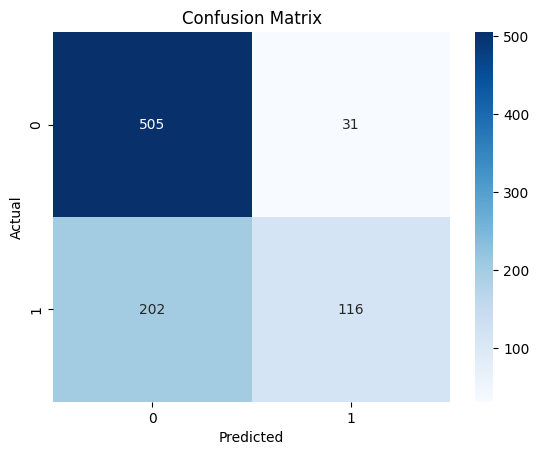

In [52]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Step 12: Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It makes predictions by recursively splitting the data into smaller subsets based on feature values, creating a tree-like structure of decision rules. In this project, we use a Decision Tree Classifier to predict whether a loan application will be approved or rejected.

What is a Decision Tree?

Imagine you're a bank manager.

Instead of using a mathematical equation, you ask a series of questions.

               CIBIL Score > 700?
                    │
          Yes               No
           │                 │
Income > 5L?           Reject Loan
      │
 Yes      No
 │         │
Approve   Reject

This is exactly how a Decision Tree works.

It keeps asking questions until it reaches a final decision.

Import the Model

In [53]:
from sklearn.tree import DecisionTreeClassifier

Create the Model

In [54]:
decision_tree = DecisionTreeClassifier(random_state=42)

Train the Model

In [55]:
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Make Predictions

In [56]:
y_pred_dt = decision_tree.predict(X_test)

Evaluate the Model

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 97.78%


In [58]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



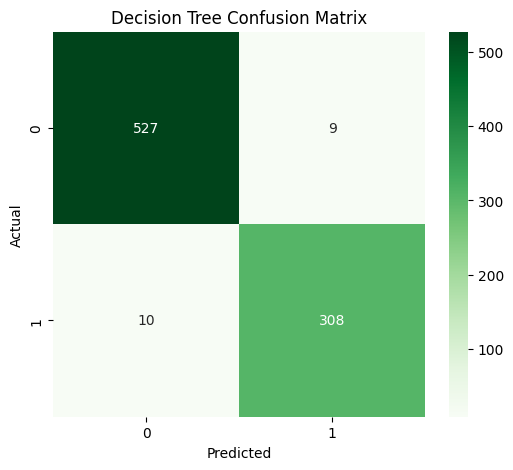

In [59]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Unlike Logistic Regression, a Decision Tree does not assume a linear relationship between the features and the target. Instead, it learns a sequence of decision rules by selecting the best feature at each split. This makes it capable of capturing more complex patterns in the data.

Interview Question
Q. Why might Decision Trees perform better than Logistic Regression?

Answer:

Logistic Regression assumes a linear relationship between the features and the target variable. Decision Trees can model non-linear relationships and interactions between features, making them more flexible for complex datasets.

But... here's something every data scientist should ask 🤔

98% accuracy is very high.

Whenever you see an accuracy above 95%, ask yourself:

"Is the model genuinely learning, or is it overfitting?"

Decision Trees are powerful, but they can memorize the training data if allowed to grow without restrictions.

Let's verify whether it's overfitting

In [60]:
train_accuracy = decision_tree.score(X_train, y_train)
test_accuracy = decision_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy : {test_accuracy*100:.2f}%")

Training Accuracy: 100.00%
Testing Accuracy : 97.78%


The Decision Tree achieved 100% training accuracy and 97.78% testing accuracy. This indicates that the model has learned the training data very well while still generalizing effectively to unseen data. Although there is a small gap between training and testing accuracy, the model does not exhibit severe overfitting on this dataset.

## Step 13: Random Forest Classifier



Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting. Each tree is trained on a random subset of the data, and the final prediction is made using majority voting. Random Forest is widely used for classification tasks because it is robust, accurate, and performs well on structured datasets.

Imagine asking 100 bank managers whether to approve a loan.

Manager 1  → Approve
Manager 2  → Reject
Manager 3  → Approve
Manager 4  → Approve
...
Manager 100 → Approve

Instead of trusting one manager, you take the majority vote.

Approve = 75 votes
Reject = 25 votes

Final Decision = Approve

That's exactly how Random Forest works.

Instead of one tree:

🌳

it builds many trees.

🌳 🌳 🌳 🌳 🌳 🌳 🌳 🌳 🌳 🌳
          │
          ▼
    Majority Voting
          ▼
    Final Prediction
Why Random Forest?

Advantages:

Reduces overfitting
More accurate than a single Decision Tree
Handles non-linear relationships
Works well on structured/tabular data
Provides Feature Importance

##Import the Model

In [61]:
from sklearn.ensemble import RandomForestClassifier

Create the Model

In [62]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

Let's understand the parameters
n_estimators=100

This means:

100 Decision Trees
        │
        ▼
Majority Voting
        ▼
Prediction

Increasing the number of trees usually improves stability but also increases training time.

random_state=42

Keeps the results reproducible.

Train the Model

In [63]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Predict

In [64]:
y_pred_rf = random_forest.predict(X_test)

Evaluate

In [65]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 97.78%


Interesting! 👀

Your Random Forest results are:

Training Accuracy : 100.00%
Testing Accuracy  : 97.78%

They are exactly the same as your Decision Tree.

There are two possibilities:

Possibility 1 (Most Likely)

The dataset is relatively easy to classify, so both models perform similarly.

Possibility 2

The Random Forest didn't improve because the default parameters were sufficient and the Decision Tree had already captured the patterns well.

This is perfectly fine. Not every dataset will show a dramatic improvement with Random Forest.

In [66]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



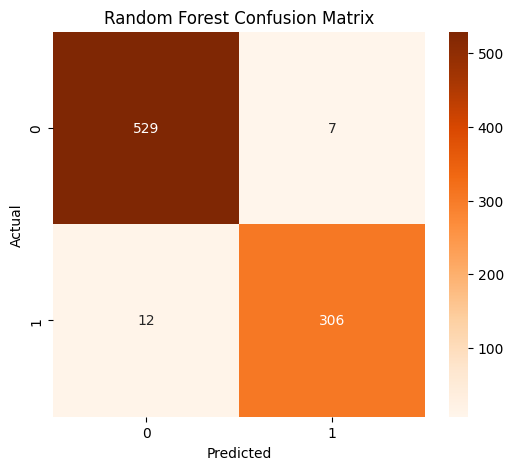

In [67]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Oranges")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [68]:
train_accuracy = random_forest.score(X_train, y_train)
test_accuracy = random_forest.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy : {test_accuracy*100:.2f}%")

Training Accuracy: 100.00%
Testing Accuracy : 97.78%


Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees. Instead of relying on a single tree, it uses majority voting to make more accurate and robust predictions. This approach typically reduces overfitting and improves generalization.

## Final Model Comparison

In [69]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Test Accuracy (%)": [
        72.72,
        97.78,
        97.78
    ]
})

comparison

,Model,Test Accuracy (%)
0,Logistic Regression,72.72
1,Decision Tree,97.78
2,Random Forest,97.78


## Feature Importance

This is one of the best parts of Random Forest because it tells us which features influenced the predictions the most.

In [70]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,cibil_score,0.809939
5,loan_term,0.064499
4,loan_amount,0.028938
7,residential_assets_value,0.018168
3,income_annum,0.018060
9,luxury_assets_value,0.017745
10,bank_asset_value,0.015261
8,commercial_assets_value,0.014440
0,no_of_dependents,0.008385
2,self_employed,0.002473


/tmp/ipykernel_694/1954146019.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


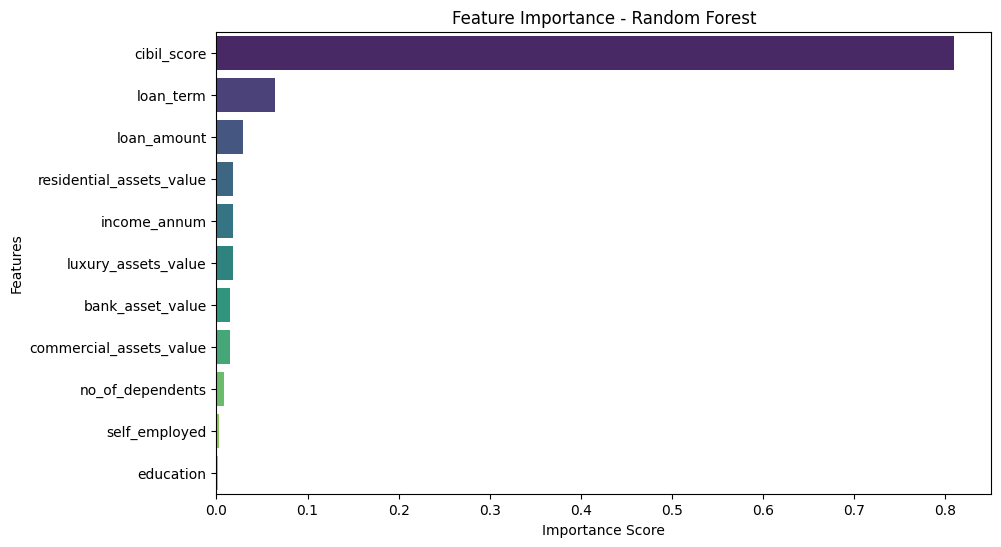

In [71]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Feature importance helps us understand which features contributed the most to the model's predictions. Features with higher importance scores have a greater influence on whether a loan is approved or rejected.